In [1]:
import os, sys
import numpy as np
import pandas as pd
from sklearn.feature_selection import f_classif

from prod_fs import ProD

from matplotlib import rc
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

In [2]:
# Initializing grids and example samples
# ---------------------------------------------------------------- #
# MultiModal
rng = np.random.default_rng(122807528840384100672342137672332424406)
# Class 1
class1_cluster1 = rng.normal(loc=0.0, scale=0.1, size=2250)
class1_cluster2 = rng.normal(loc=0.5, scale=0.1, size=750)
class1mm = np.concatenate((class1_cluster1, class1_cluster2))

class1mm_calcsd = np.std(class1mm, ddof=1)

# Class 2
class2mm = rng.normal(loc=3*class1mm_calcsd, scale=0.14929775, size=3000)
# ---------------------------------------------------------------- #

# ---------------------------------------------------------------- #
# Normal
rng = np.random.default_rng(122807528840384100672342137672332424406)
# Class 1
class1 = rng.normal(loc=0.0, scale=1.0, size=3000)
class1_calcsd = np.std(class1, ddof=1)

# Class 2
class2 = rng.normal(loc=3*class1_calcsd, scale=1.0, size=3000)
# ---------------------------------------------------------------- #

In [3]:
# Routine
def _run(c0, c1, _ax, _fname):
    # Initializing the dataset
    X = pd.DataFrame(
        data=np.zeros((len(c0)+len(c1), 2)), columns=["Feature", "Class"]
    )
    X.iloc[:len(c0), 0] = c0
    
    X.iloc[len(c0):, 0] = c1
    X.iloc[len(c0):, 1] = 1
    
    y = X["Class"]
    X.drop(columns=["Class"], inplace=True)
    X = X.values
    ProdRanker = ProD(k=2, lower_end=0.0, upper_end=1.0, bw_method="scott")
    ProdRanker.fit(X, y)
    
    # ANOVA F-Test
    f_statistic, p_values = f_classif(X, y)
    print(f"F-Stat from scikit-learn's ANOVA  : {f_statistic}")
    print(f"P-Value from scikit-learn's ANOVA : {p_values}")
    
    # One-way ANOVA per hand for educational purposes
    # 1. Sum of squared deviations
    G = X.sum()       # grand total
    T0 = c0.sum() # group total of class 0
    T1 = c1.sum() # group total of class 1
    
    N = X.shape[0]       # grand sample size
    
    SS_total = (X**2).sum() - ((G**2)/N)
    
    SS_between = (T0**2)/len(c0) + (T1**2)/len(c1) - (G**2)/N
    SS_within  = (X**2).sum() - ((T0**2)/len(c0) + (T1**2)/len(c1))
    
    # 2. Degrees of freedom
    df_total = N-1
    df_between = 2-1
    df_within = N-2
    
    # 3. Mean squares of variability
    MS_between = SS_between / df_between
    MS_within  = SS_within / df_within
    
    # 4. F-ratio
    F = MS_between / MS_within
    print(f"\nManually computed F-Stat : {F}")
    
    # 5. Proportion of Explained Variance
    etaSquared = SS_between / SS_total
    print(f"Manually computed Eta^2  : {etaSquared}")
    
    # Plot overlapping areas
    ProdRanker.plot_overlapAreas(
        0, _combinations=None, _ax=_ax, legend="intersection",
        legend_fIndex=_fname
    )

    # Get means of normalized feature vectors
    mean0 = ProdRanker.y_segregatedGroup[0.0][0].mean()
    mean1 = ProdRanker.y_segregatedGroup[1.0][0].mean()
    meanTotal = np.append(
        ProdRanker.y_segregatedGroup[0.0][0], ProdRanker.y_segregatedGroup[1.0][0]
    )
    meanTotal = meanTotal.mean()

    title = f"F-Ratio: {int(np.round(F))} | "
    title += r"$\eta^{2}$: "
    title += str(np.round(etaSquared, 3))
    _ax.set_title(
        title, horizontalalignment="left", loc="left"
    )

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
F-Stat from scikit-learn's ANOVA  : [13113.85541693]
P-Value from scikit-learn's ANOVA : [0.]

Manually computed F-Stat : 13113.855416927094
Manually computed Eta^2  : 0.6861633855450969
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
F-Stat from scikit-learn's ANOVA  : [13113.60005081]
P-Value from scikit-learn's ANOVA : [0.]

Manually computed F-Stat : 13113.600050810635
Manually computed Eta^2  : 0.6861591921108882


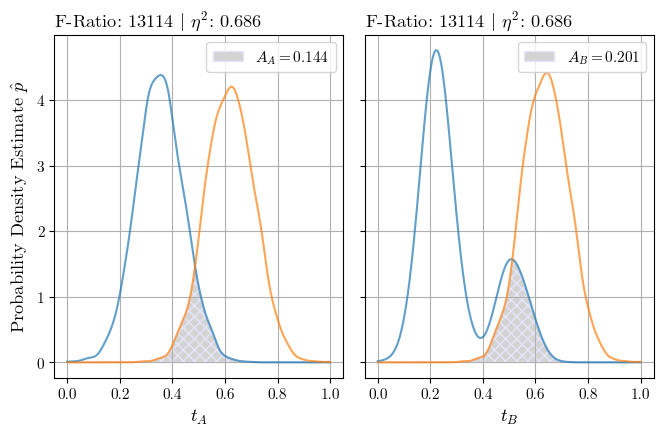

In [4]:
# Plot
plotlength = 9.0
fig, axs = plt.subplots(
    1, 2, figsize=(plotlength/1.33, plotlength/2), sharey=True
)
_run(class1, class2, axs[0], 'A')
_run(class1mm, class2mm, axs[1], 'B')

# x-ticks
axs[0].set_xticks(np.arange(0.0, 1.2, 0.2))
axs[1].set_xticks(np.arange(0.0, 1.2, 0.2))

# x-label
axs[0].set_xlabel(r"$t_A$")
axs[1].set_xlabel(r"$t_B$")

# y-label
axs[0].set_ylabel(r"Probability Density Estimate $\hat{p}$", fontsize='large')

# turn on grid
axs[0].grid(visible=True, which="major", axis="both")
axs[1].grid(visible=True, which="major", axis="both")

plt.tight_layout()